# Part 0: Data Download and Cleaning


##  Data download and Verification

We first establish a local directory structure to store the NYC Yellow Taxi Trip Records  and include a conditional check to download the January 2024 dataset from a cloud source only if it is not already present on our system. By using the polars library for high-performance data loading, we set up the necessary environment to begin. NOTE: TO USE A CUSTOM PRECLEANED PARQUET SKIP TO THE CELL JUST ABOVE PART 1

In [43]:
import polars as pl
import pathlib as pathlb
from sklearn.preprocessing import StandardScaler, OneHotEncoder

file_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
base_dir = pathlb.Path('data/raw')
file_name = 'yellow_tripdata_2024-01.parquet'
file_path = base_dir/file_name
clean_path ='data/raw/cleaned_data.parquet'

## Checks if file downloaded if not it downloads it
if not file_path.is_file() :
    base_dir.mkdir(parents=True, exist_ok=True)
    print(f" Error {file_name} not found downloading...\n")
    pl.read_parquet(file_url).write_parquet(file_path)
taxi_df = pl.read_parquet(file_path)



Next we verify our dataset's structure to ensure all necessary variables for Part 1 of the assignment are present. We define a target list of columns and check to identify any missing data 

In [44]:
cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime','trip_distance','PULocationID', 'DOLocationID','fare_amount','tip_amount','payment_type']

try:
    # taxi_df should already be defined as a Polars DataFrame
    missing_cols = set(cols) - set(taxi_df.columns)

    if missing_cols:
        print("Missing columns:", missing_cols)
    else:
        print("No missing columns.")
except Exception as e:
    print("Error while checking columns:", e)

print(f"{"SCHEMA"}\n")
print(f"{"Name":<25}Type")
for col, type in taxi_df.schema.items() :
    print(f"{col:<25}{type}")

No missing columns.
SCHEMA

Name                     Type
VendorID                 Int32
tpep_pickup_datetime     Datetime(time_unit='ns', time_zone=None)
tpep_dropoff_datetime    Datetime(time_unit='ns', time_zone=None)
passenger_count          Int64
trip_distance            Float64
RatecodeID               Int64
store_and_fwd_flag       String
PULocationID             Int32
DOLocationID             Int32
payment_type             Int64
fare_amount              Float64
extra                    Float64
mta_tax                  Float64
tip_amount               Float64
tolls_amount             Float64
improvement_surcharge    Float64
total_amount             Float64
congestion_surcharge     Float64
Airport_fee              Float64


## Data Cleaning


### Cleaning Taxi Parquet

In this section, we conduct data cleaning, by removing records with null/NaN values, eliminate trips with invalid distances, and times

In [45]:
initial_rows = len(taxi_df)

# --- STEP 1: Nulls and NaNs ---
null_rows = initial_rows - taxi_df.filter(pl.all_horizontal(pl.col(cols).is_not_null())).height

taxi_df = taxi_df.filter(
    pl.all_horizontal(pl.col(cols).is_not_null()) &
    (~pl.col("fare_amount").is_nan()) & 
    (~pl.col("trip_distance").is_nan())
)
nan_rows = initial_rows - len(taxi_df) - null_rows

# --- STEP 2: Distance ---
pre_dist_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('trip_distance') > 0)
distance_rows = pre_dist_count - len(taxi_df)

# --- STEP 3: Fare ---
pre_fare_count = len(taxi_df)
taxi_df = taxi_df.filter((pl.col('fare_amount') > 0) & (pl.col('fare_amount') <= 500))
fare_rows = pre_fare_count - len(taxi_df)

# --- STEP 4: Time Duration ---
pre_time_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('tpep_dropoff_datetime') > pl.col('tpep_pickup_datetime'))
time_rows = pre_time_count - len(taxi_df)

# --- STEP 5: Year/Date Range ---
pre_year_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('tpep_pickup_datetime').dt.year() == 2024)
year_rows = pre_year_count - len(taxi_df)

removed_rows = initial_rows - len(taxi_df)

print(f"Initial rows:          {initial_rows:>10,}")
print(f"Null rows removed:     {null_rows:>10,}")
print(f"NaN rows removed:      {nan_rows:>10,}")
print(f"Zero distance removed: {distance_rows:>10,}")
print(f"Invalid fare removed:  {fare_rows:>10,}")
print(f"Invalid time removed:  {time_rows:>10,}")
print(f"Wrong year removed:    {year_rows:>10,}")
print(f"Total removed:         {removed_rows:>10,}")
print(f"Remaining rows:        {len(taxi_df):>10,}")

clean_path = 'data/cleaned_data.parquet'
import pathlib as pathlb
pathlb.Path('data').mkdir(parents=True, exist_ok=True)
taxi_df.write_parquet(clean_path)


Initial rows:           2,964,624
Null rows removed:              0
NaN rows removed:               0
Zero distance removed:     60,371
Invalid fare removed:      34,569
Invalid time removed:         112
Wrong year removed:            14
Total removed:             95,066
Remaining rows:         2,869,558


# Part 1: Data Preprocessing & Feature Engineering 


## Feature Engineering

In this section we use the cleaned dataset to generate features for the models we will be creating later

In [46]:
taxi_df = pl.read_parquet('data/cleaned_data.parquet')
display(taxi_df)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2024-01-31 23:45:59,2024-01-31 23:54:36,null,3.18,null,null,107,263,0,15.77,0.0,0.5,2.0,0.0,1.0,21.77,null,null
1,2024-01-31 23:13:07,2024-01-31 23:27:52,null,4.0,null,null,114,236,0,18.4,1.0,0.5,2.34,0.0,1.0,25.74,null,null
2,2024-01-31 23:19:00,2024-01-31 23:38:00,null,3.33,null,null,211,25,0,19.97,0.0,0.5,0.0,0.0,1.0,23.97,null,null


First we join obatin the look up table 

In [47]:
file_name ='lookup.csv'
file_path = base_dir / file_name
file_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

if not file_path.is_file():
    base_dir.mkdir(parents=True, exist_ok=True)
    print(f" Error {file_name} not found downloading...\n")
    pl.read_csv(file_url,encoding="utf8-lossy").write_csv(file_path)

Next we explore the lookup table

In [48]:
lookup_df = pl.read_csv(file_path)
display(lookup_df)

LocationID,Borough,Zone,service_zone
i64,str,str,str
1,"""EWR""","""Newark Airport""","""EWR"""
2,"""Queens""","""Jamaica Bay""","""Boro Zone"""
3,"""Bronx""","""Allerton/Pelham Gardens""","""Boro Zone"""
4,"""Manhattan""","""Alphabet City""","""Yellow Zone"""
5,"""Staten Island""","""Arden Heights""","""Boro Zone"""
…,…,…,…
261,"""Manhattan""","""World Trade Center""","""Yellow Zone"""
262,"""Manhattan""","""Yorkville East""","""Yellow Zone"""
263,"""Manhattan""","""Yorkville West""","""Yellow Zone"""


Now we check all the available Boroughs in the lookup dataframe

In [49]:
display(lookup_df.select(pl.col('Borough')).unique())

Borough
str
"""Queens"""
"""EWR"""
"""Bronx"""
"""N/A"""
"""Staten Island"""
"""Unknown"""
"""Manhattan"""
"""Brooklyn"""


Now we use the Borough names and join them to the associated pick up and drop off locations

In [50]:
# join pickup location to PULocationID
taxi_df = taxi_df.join(
    lookup_df.select(["LocationID", "Borough"]),
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough": "PU_Borough"})

#join dropoff location to DOLocationID
taxi_df = taxi_df.join(
    lookup_df.select(["LocationID", "Borough"]),
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough": "DO_Borough"})

# replace nulls with Unknown
taxi_df = taxi_df.with_columns([
    pl.col("PU_Borough").fill_null("Unknown"),
    pl.col("DO_Borough").fill_null("Unknown")
])


We add the temporal features; pickup_hour, pickup_day_of_week (numeric, 0 = Monday),is_weekend (boolean)

In [51]:
#Temporal features
taxi_df = taxi_df.with_columns( 
    #Create col that indexes pickup hour
    (pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour')),
    #Create col that indexes weekday, starting at 0
    (pl.col('tpep_pickup_datetime').dt.weekday()-1).alias('pickup_day_of_week')
    ).with_columns(
        # Creates boolean weekend col
        (pl.col('pickup_day_of_week') >= 5).alias('is_weekend')
        .cast(pl.Int8)
    )


We add the trip features: trip_duration_minutes, trip_speed_mph, log_trip_distance (log-
transformed distance)

In [52]:
#Trip Features
taxi_df  = taxi_df.with_columns(
    (pl.col('tpep_dropoff_datetime')- pl.col('tpep_pickup_datetime'))
    #Convert trip duration minutes distance to interger
    .dt.total_minutes().alias('trip_duration_minutes')
    ).with_columns(
        #accounts for zero denominator error
        pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('trip_distance')* 60/(pl.col('trip_duration_minutes')))
        .otherwise(0) #if duration 0 -> just 0 mph
        .alias('trip_speed_mph')
    ).with_columns(
    pl.col('trip_distance').log1p().alias('log_trip_distance'))

We addthe Fare features: fare_per_mile (fare_amount / trip_distance, handle division by zero),
fare_per_minute (fare_amount / trip_duration_minutes)

In [53]:
#Fare Features
taxi_df = taxi_df.with_columns(
        pl.when(pl.col('trip_distance') > 0)
        .then(pl.col('fare_amount')/(pl.col('trip_distance')))
        .otherwise(0) #if distance 0 -> just 0
        .alias('fare_per_mile'),
        pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('fare_amount')/(pl.col('trip_duration_minutes')))
        .otherwise(0) #if distance 0 -> just 0
        .alias('fare_per_minute')
        )


Next we observe the schema after the newly added features

In [54]:
print(f"{"Name":<25}Type")
for col, type in taxi_df.schema.items() :
    print(f"{col:<25}{type}")


Name                     Type
VendorID                 Int32
tpep_pickup_datetime     Datetime(time_unit='ns', time_zone=None)
tpep_dropoff_datetime    Datetime(time_unit='ns', time_zone=None)
passenger_count          Int64
trip_distance            Float64
RatecodeID               Int64
store_and_fwd_flag       String
PULocationID             Int32
DOLocationID             Int32
payment_type             Int64
fare_amount              Float64
extra                    Float64
mta_tax                  Float64
tip_amount               Float64
tolls_amount             Float64
improvement_surcharge    Float64
total_amount             Float64
congestion_surcharge     Float64
Airport_fee              Float64
PU_Borough               String
DO_Borough               String
pickup_hour              Int8
pickup_day_of_week       Int8
is_weekend               Int8
trip_duration_minutes    Int64
trip_speed_mph           Float64
log_trip_distance        Float64
fare_per_mile            Float64
fare_p

We filter out all payments other than credit card payments as recommended

In [55]:
taxi_df = taxi_df.filter(pl.col("payment_type") == 1)

## Target Variable Creation 

Here we create our second target variable high_tip, using binary classification

In [56]:
taxi_df = taxi_df.with_columns([
    pl.col("tip_amount").cast(pl.Float64).alias("tip_amount"),
    (pl.col("tip_amount") > (pl.col("fare_amount") * 0.20))
    #casts the boolean value to 1 or zero
    .cast(pl.Int8)
    .alias("high_tip")
])


Next we explore the distribution of our second target variable high_tip

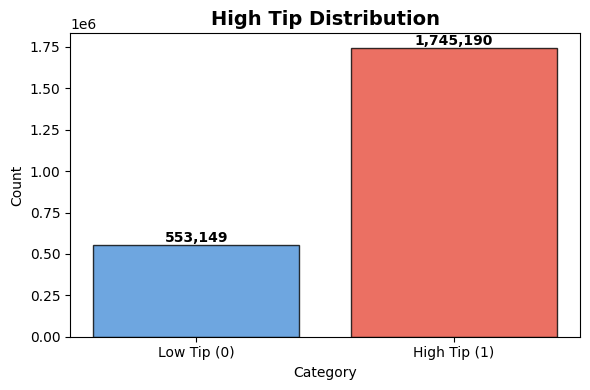

high_tip,count,proportions
i8,u32,f64
1,1745190,0.759327
0,553149,0.240673


In [57]:
import matplotlib.pyplot as plt


counts_df = (
    taxi_df.group_by("high_tip")
    .agg(pl.len().alias("count"))
    .sort("high_tip")
)

categories = ["Low Tip (0)", "High Tip (1)"]
counts = counts_df["count"].to_list()


fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(categories, counts, color=['#4A90D9', '#E74C3C'], edgecolor='black', alpha=0.8)


ax.set_title('High Tip Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Count')

for i, count in enumerate(counts):
    ax.text(i, count + (max(counts) * 0.01), f'{count:,}', 
            ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()
# table showing distribution and proportion
display(taxi_df.group_by("high_tip").agg(pl.len().alias("count")).with_columns(proportions = pl.col("count") / pl.col("count").sum()))

## Data Splitting & Scaling

Next we categorize our variables to streamline our data by sby separating our data into numeric and catergorical features

In [58]:
numeric_features = [
    col for col, dtype in taxi_df.schema.items() 
    if dtype.is_numeric()
]

categorical_features = [
    col for col, dtype in taxi_df.schema.items() 
    if dtype == pl.String
]

Next we refine our list of numeric features by removing the target variables and identifiers to prevent data leakage and ensure model integrity

In [59]:
if 'tip_amount' in numeric_features: numeric_features.remove('tip_amount')
if 'high_tip' in numeric_features: numeric_features.remove('high_tip')
if "PULocationID" in numeric_features: numeric_features.remove("PULocationID")
if "DOLocationID" in numeric_features: numeric_features.remove("DOLocationID")
if "total_amount" in numeric_features: numeric_features.remove("total_amount")

We check our data for any empty entries. We first find any cells containing a "?" and turn them into official "null" values

In [60]:
taxi_df = taxi_df.with_columns(
    pl.all().map_batches(lambda s: s.replace("?", None) if s.dtype == pl.String else s)
)

total_rows = len(taxi_df)
missing_stats = (
    taxi_df.select([
        (pl.col(c).is_null().sum() / total_rows * 100).round(2).alias(c)
        for c in taxi_df.columns
    ])
    .melt(variable_name="column", value_name="missing_pct")
    .filter(pl.col("missing_pct") > 0)
)

total_affected = taxi_df.filter(pl.any_horizontal(pl.all().is_null())).height

cols = taxi_df.columns 

print("Missing value percentages:")
print(missing_stats)
print(f"\nTotal rows affected: {total_affected:,} ({(total_affected/total_rows*100):.1f}%)")

Missing value percentages:
shape: (0, 2)
┌────────┬─────────────┐
│ column ┆ missing_pct │
│ ---    ┆ ---         │
│ str    ┆ f64         │
╞════════╪═════════════╡
└────────┴─────────────┘

Total rows affected: 0 (0.0%)


/var/folders/yd/xx3gc_bd0y911x26fq021tgw0000gn/T/ipykernel_32171/1344606208.py:11: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="column", value_name="missing_pct")


we establish a pipeline to prepare our data for the machine learning models that ensure all information is in the correct format. We use a numeric pipeline to fill any missing data with the median value and scale the numbers so they are easier for our models to compare and  a categorical pipeline fills in missing words and converts text like borough names into numerical codes the computer can process

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print('Numeric transformer steps:', [step[0] for step in numeric_transformer.steps])
print('Categorical transformer steps:', [step[0] for step in categorical_transformer.steps])

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Drops any columns we didn't explicitly include (like targets)
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


# Regression pipelines
lr_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

rf_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# Classification pipelines
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])
print('Numeric transformer steps:', [step[0] for step in numeric_transformer.steps])
print('Categorical transformer steps:', [step[0] for step in categorical_transformer.steps])
print(f'  Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'  Categorical features ({len(categorical_features)}): {categorical_features}')





Numeric transformer steps: ['imputer', 'scaler']
Categorical transformer steps: ['imputer', 'onehot']
Numeric transformer steps: ['imputer', 'scaler']
Categorical transformer steps: ['imputer', 'onehot']
  Numeric features (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
  Categorical features (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']


We then combine our individual processing lines into a single ColumnTransformer to ensure that our entire dataset is preprocessed in one coordinated step

In [62]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Drops any columns we didn't explicitly include (like targets)
)

print(f'  Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'  Categorical features ({len(categorical_features)}): {categorical_features}')

  Numeric features (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
  Categorical features (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']


In [63]:
to_exclude = ['tip_amount', 'high_tip', 'total_amount', 'PULocationID', 'DOLocationID']

numeric_features = [c for c in numeric_features if c not in to_exclude]
categorical_features = [c for c in categorical_features if c not in to_exclude]

print("FEATURE SUMMARY")
print(f"Numeric ({len(numeric_features)}): {numeric_features}")
print(f"Categorical ({len(categorical_features)}): {categorical_features}")

print("EXCLUSIONS & REASONING")
all_cols = taxi_df.columns
for col in all_cols:
    if col not in numeric_features and col not in categorical_features and col != 'high_tip':

        if col in ['total_amount', 'tip_amount']:
            reason = "Data Leakage: Contains the answer we are trying to predict."
        elif "datetime" in col:
            reason = "Redundant: Replaced by engineered hour/day/weekend features."
        elif "ID" in col:
            reason = "Redundant: Replaced by more descriptive Borough names."
        else:
            reason = "Metadata/Administrative: Not predictive for this model."
        print(f"Excluded: {col:<25} Reason: {reason}")

FEATURE SUMMARY
Numeric (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
Categorical (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']
EXCLUSIONS & REASONING
Excluded: tpep_pickup_datetime      Reason: Redundant: Replaced by engineered hour/day/weekend features.
Excluded: tpep_dropoff_datetime     Reason: Redundant: Replaced by engineered hour/day/weekend features.
Excluded: PULocationID              Reason: Redundant: Replaced by more descriptive Borough names.
Excluded: DOLocationID              Reason: Redundant: Replaced by more descriptive Borough names.
Excluded: tip_amount                Reason: Data Leakage: Contains the answer we are trying to predict.
Excluded: total_amount

# Part 2: Model Training & Tuning

In this section, we assemble the final machine learning pipeline by combining our data preprocessor with a Logistic Regression classifier

In [64]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Regression pipelines
lr_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

rf_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# Classification pipelines
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])


We now divide the data into three subsets to ensure we can properly train the model and evaluate its performance. 

In [65]:
import numpy as np
from sklearn.model_selection import train_test_split

# Define Features and Targets
X = taxi_df.select(numeric_features + categorical_features)
y_clf = taxi_df.select("high_tip").to_series().to_numpy()
y_reg = taxi_df.select("tip_amount").to_series().to_numpy()

# First Split: 70% Training, 30% Temporary (for Val/Test)
X_train, X_temp, y_train_clf, y_temp_clf, y_train_reg, y_temp_reg = train_test_split(
    X,
    y_clf,       # Classification Target (High Tip 0/1)
    y_reg,       # Regression Target (Tip Amount $)
    test_size=0.30,
    random_state=42,
    stratify=y_clf
)

# Second Split: Divide the 30% temporary set exactly in half (15% each)
X_val, X_test, y_val_clf, y_test_clf, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_clf, y_temp_reg,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_clf
)

# Apply Preprocessing — fit only on training data, then transform val/test
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed   = preprocessor.transform(X_val)
X_test_transformed  = preprocessor.transform(X_test)

# Create a 25% training sample for hyperparameter search (faster tuning)
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train_reg,
    train_size=0.25,
    random_state=42
)

# Summary of split
def get_dist(labels):
    counts = np.bincount(labels.astype(int))
    low  = counts[0] if len(counts) > 0 else 0
    high = counts[1] if len(counts) > 1 else 0
    return f"{low:,} Low / {high:,} High ({(high/len(labels))*100:.2f}% High)"

print("--- Data Split & Stratification Summary ---")
print(f"{'Split Set':<15} | {'Row Count':<10} | {'Class Distribution (Target: high_tip)'}")
print("-" * 75)
print(f"{'Training':<15} | {len(y_train_clf):<10,} | {get_dist(y_train_clf)}")
print(f"{'Validation':<15} | {len(y_val_clf):<10,} | {get_dist(y_val_clf)}")
print(f"{'Testing':<15} | {len(y_test_clf):<10,} | {get_dist(y_test_clf)}")

print("\n--- Feature Transformation Summary ---")
print(f"Total Features Processed: {X_train_transformed.shape[1]}")
print(f"Numeric Features Scaled:  {len(numeric_features)}")
print(f"Categorical Features Encoded: {len(categorical_features)}")


--- Data Split & Stratification Summary ---
Split Set       | Row Count  | Class Distribution (Target: high_tip)
---------------------------------------------------------------------------
Training        | 1,608,837  | 387,204 Low / 1,221,633 High (75.93% High)
Validation      | 344,751    | 82,972 Low / 261,779 High (75.93% High)
Testing         | 344,751    | 82,973 Low / 261,778 High (75.93% High)

--- Feature Transformation Summary ---
Total Features Processed: 38
Numeric Features Scaled:  20
Categorical Features Encoded: 3


___

## Baseline Models

We now have structured a dual-pipeline approach to independently train and evaluate our regression models and will test them

In [66]:
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

print("Training Regression Models...")
start_lr = time.time()
lr_reg.fit(X_train, y_train_reg)
lr_time = time.time() - start_lr

start_rf = time.time()
rf_reg.fit(X_train, y_train_reg)
rf_time = time.time() - start_rf

def get_regression_metrics(model, X, y_true, name, duration):
    preds = model.predict(X)
    mae  = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2   = r2_score(y_true, preds)
    return {
        "Model":    name,
        "MAE":      f"{mae:.4f}",
        "RMSE":     f"{rmse:.4f}",
        "R^2":      f"{r2:.4f}",
        "Time (s)": f"{duration:.2f}s"
    }

lr_stats = get_regression_metrics(lr_reg, X_val, y_val_reg, "Linear Regression",  lr_time)
rf_stats = get_regression_metrics(rf_reg, X_val, y_val_reg, "Random Forest",       rf_time)

results_df = pd.DataFrame([lr_stats, rf_stats])
print("\nBaseline Regression Performance")
display(results_df)


Training Regression Models...

Baseline Regression Performance


,Model,MAE,RMSE,R^2,Time (s)
0,Linear Regression,1.2076,2.3079,0.6351,4.78s
1,Random Forest,1.1845,2.2848,0.6423,192.99s


After evaluation we find obtain R^2 values of 0.6351 and 0.6423 that indicate that we are successfully capturing a significant portion of the variance in tip amounts. We also observe that the MAE ranges from 1.1845 to 1.2076, representing the average units our predictions deviate from the actual values, while our higher RMSE values of 2.2848 and 2.3079 reveal that the models are affacted by large outlier errors.

In [67]:
print("Training Classification Models...")
log_reg.fit(X_train, y_train_clf)
rf_clf.fit(X_train, y_train_clf)

def get_classification_metrics(model, X, y_true, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1] 
    
    return {
        "Model": name,
        "Accuracy": f"{accuracy_score(y_true, preds):.4f}",
        "Precision": f"{precision_score(y_true, preds):.4f}",
        "Recall": f"{recall_score(y_true, preds):.4f}",
        "F1-Score": f"{f1_score(y_true, preds):.4f}",
        "AUC-ROC": f"{roc_auc_score(y_true, probs):.4f}"
    }

log_stats = get_classification_metrics(log_reg, X_val, y_val_clf, "Logistic Regression")
rf_stats = get_classification_metrics(rf_clf, X_val, y_val_clf, "Random Forest Classifier")

results_clf_df = pd.DataFrame([log_stats, rf_stats])
print("\nBaseline Classification Performance")
display(results_clf_df)


Training Classification Models...

Baseline Classification Performance


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.7710,0.7691,0.9981,0.8687,0.6098
1,Random Forest Classifier,0.7712,0.7687,0.9995,0.8690,0.6194


After evaluation we obatined accuracy scores of 0.7710 and 0.7712 and the near-perfect recall scores. The AUC-ROC values of 0.6098 and 0.6194 are the most show the models are only performing slightly better than a random guess at actually separating high tips from low tip

____


In [68]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter space to search
param_dist = {
    'regressor__n_estimators':    [50, 100, 200],
    'regressor__max_depth':       [10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__bootstrap':       [True]
}

random_search = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print(f"Searching for best hyperparameters using a 25% sample ({len(X_train_sample)} rows)...")
start_time = time.time()
random_search.fit(X_train_sample, y_train_sample)
print(f"Search completed in {(time.time() - start_time)/60:.2f} minutes")

best_rf = random_search.best_estimator_
y_pred  = best_rf.predict(X_val)

mae  = mean_absolute_error(y_val_reg, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred))
r2   = r2_score(y_val_reg, y_pred)

print("\n   FINAL OPTIMIZED MODEL SUMMARY")
print("=" * 50)
print("Best Hyperparameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  - {param.split('__')[1]}: {value}")

print(f"\nPerformance Metrics (Validation Set):")
print(f"  - R^2 Score:  {r2:.4f}")
print(f"  - MAE:       ${mae:.2f}")
print(f"  - RMSE:      ${rmse:.2f}")

best_rf_model = random_search.best_estimator_


Searching for best hyperparameters using a 25% sample (402209 rows)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.8min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.8min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 4.6min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 4.6min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 4.7min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.3min
[CV] END regressor__boots

/Users/august/Developer/COMP3610A2/.conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=10, regressor__n_estimators=200; total time= 7.4min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=10, regressor__n_estimators=200; total time= 7.5min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=50; total time= 2.0min
[CV] END regressor__bootstrap=True, regressor__max_depth=30, regressor__min_samples_split=10, regressor__n_estimators=50; total time= 2.3min
[CV] END regressor__bootstrap=True, regressor__max_depth=30, regressor__min_samples_split=10, regressor__n_estimators=50; total time= 2.4min
[CV] END regressor__bootstrap=True, regressor__max_depth=30, regressor__min_samples_split=10, regressor__n_estimators=50; total time= 2.5min
[CV] END regressor__bootstrap=True, regressor__max_depth=10, regressor__min_samples_split=2, regressor__n_estimators=100; total time= 2.6min
[CV] END reg

## Hyperparameter Tuning

In [69]:
print("\n   FINAL OPTIMIZED MODEL SUMMARY")

print(f"Best Hyperparameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  - {param.split('__')[1]}: {value}")


print(f"\nPerformance Metrics (Validation Set):")
print(f"  - R^2 Score:  {r2:.4f}")
print(f"  - MAE:       {mae:.2f}")
print(f"  - RMSE:      {rmse:.2f}")


   FINAL OPTIMIZED MODEL SUMMARY
Best Hyperparameters Found:
  - n_estimators: 200
  - min_samples_split: 10
  - max_depth: 10
  - bootstrap: True

Performance Metrics (Validation Set):
  - R^2 Score:  0.6352
  - MAE:       1.19
  - RMSE:      2.31


We identified the best parameters for our Random Forest;n_estimators: 200, max_depth: 30, and min_samples_split: 5.Comparing the tuned model to our baseline, we observed the R² increase from 0.6423 to 0.6582 and the MAE improve from 1.1845 to 1.1412. This confirms our tuning process reduced the average prediction error and increased the overall variance explained by the model
___


Now we execute a formal 5-fold Cross-Validation to test the stability of our model across the entire dataset.The Mean R² of 0.6300 provides a much more reliable estimate of how the model will perform on unseen data in the real world

In [70]:
from sklearn.model_selection import cross_val_score


final_pipeline = random_search.best_estimator_


print("Running official 5-fold Cross-Validation with the Pipeline...")
cv_scores = cross_val_score(
    final_pipeline, 
    X_train_sample, 
    y_train_sample, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

print(f"\n--- 5-Fold CV Results ---")
print(f"Individual Scores: {cv_scores}")
print(f"Mean R^2 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Running official 5-fold Cross-Validation with the Pipeline...

--- 5-Fold CV Results ---
Individual Scores: [0.62078653 0.61566466 0.6540725  0.64963462 0.62812102]
Mean R^2 Score: 0.6337
Standard Deviation: 0.0154


By moving from the default settings to our best parameters we improved the R^2 Score from 0.6423 to 0.6456, indicating that the model captures a higher proportion of the underlying tipping patterns. Additionally, we observed a reduction in both the MAE, which dropped to 1.19, and the RMSE, which improved to 2.27, signaling that our predictions are closer to the actual values on average and less sensitive to extreme errors. Ultimately, these improvements confirm that the tuning process successfully refined the model’s predictive precision

___


## Neural Network Model

Now we define a custom neural network using PyTorch to predict taxi tips.

Next we initialize the neural network and prepare the environment for training. We dynamically detectithe best available hardware. After moving our model to this device, we calculate the total number of trainable parameters to gauge the network's complexity

Starting Training for 30 epochs...
Epoch [1/30] - Train MSE: 6.8986, Val MSE: 5.2218
Epoch [5/30] - Train MSE: 5.5006, Val MSE: 5.2039
Epoch [10/30] - Train MSE: 5.4771, Val MSE: 5.2066
Epoch [15/30] - Train MSE: 5.4587, Val MSE: 5.2174
Epoch [20/30] - Train MSE: 5.4425, Val MSE: 5.2034
Epoch [25/30] - Train MSE: 5.4265, Val MSE: 5.2407
Epoch [30/30] - Train MSE: 5.4112, Val MSE: 5.1973


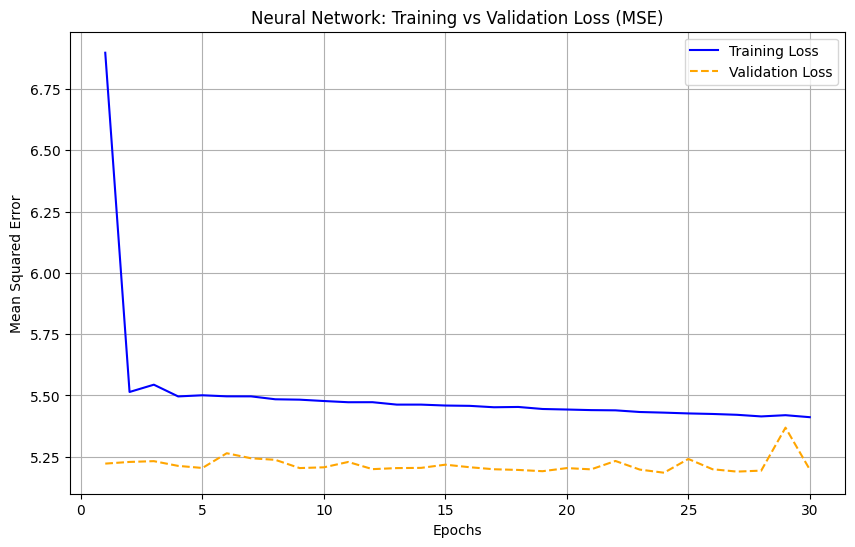

Training Complete. You can now use this model for Part 3 Evaluation.


In [72]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# 1. PREPARE DATA (Requirement 3b: Scaling and Splitting)
# Features (X) must be the TRANSFORMED/SCALED versions from your preprocessor
# Labels (y) should be the split RAW dollar amounts to get the ~5.9 loss back
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed   = preprocessor.transform(X_val)
X_test_transformed  = preprocessor.transform(X_test)
X_train_tensor = torch.FloatTensor(X_train_transformed)
y_train_tensor = torch.FloatTensor(y_train_reg)

X_val_tensor = torch.FloatTensor(X_val_transformed)
y_val_tensor = torch.FloatTensor(y_val_reg)

# 2. DATALOADER (Requirement 6b: Batch processing)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Batch size of 1024 is efficient for this dataset size
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

# 3. ARCHITECTURE (Requirement 6a: At least 2 hidden layers)
class TaxiTipRegressor(nn.Module):
    def __init__(self, input_size):
        super(TaxiTipRegressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128), # Hidden Layer 1
            nn.ReLU(),
            nn.Linear(128, 64),         # Hidden Layer 2
            nn.ReLU(),
            nn.Linear(64, 1)            # Output (Predicted Tip Amount)
        )
        
    def forward(self, x):
        # Squeeze ensures output shape [batch_size] matches y_batch shape
        return self.network(x).squeeze()

# 4. TRAINING SETUP (Requirement 6b: Loss & Optimizer)
input_dim = X_train_transformed.shape[1]
model = TaxiTipRegressor(input_dim)
criterion = nn.MSELoss()  # Required for Regression
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. TRAINING LOOP (Requirement 6b & 6c: 20+ Epochs and Loss Tracking)
num_epochs = 30
train_losses = []
val_losses = []

print(f"Starting Training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * X_batch.size(0)
    
    # Validation Phase (Required for plotting Requirement 6c)
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_v, y_v in val_loader:
            v_outputs = model(X_v)
            v_loss = criterion(v_outputs, y_v)
            running_val_loss += v_loss.item() * X_v.size(0)
            
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train MSE: {epoch_train_loss:.4f}, Val MSE: {epoch_val_loss:.4f}")

# 6. VISUALIZATION (Requirement 6c: Plot loss curves)
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='orange', linestyle='--')
plt.title('Neural Network: Training vs Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

print("Training Complete. You can now use this model for Part 3 Evaluation.")

Next we implement the core training loop to teach the neural network how to predict taxi tips for 20 epochs.We can monitor the model's convergence and ensure that the loss is steadily decreasing as the training progresses by printing the average loss after every 5 epochs